In [28]:
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
PARQUET_PATH = r"G:\PRASAD\EDA_project\citibike_weather_2025.parquet"
con = duckdb.connect()

In [8]:
import os

size_gb = os.path.getsize(PARQUET_PATH) / (1024**3)
print(f"Parquet file size: {size_gb:.2f} GB")

Parquet file size: 1.65 GB


### NO. OF ROWS/ COLUMNS AND DESCRIPTION

In [9]:
con.execute(f"""
SELECT 
    COUNT(*) AS total_rows
FROM '{PARQUET_PATH}'
""").fetchdf()

,total_rows
0,29485571


In [10]:
import pyarrow.parquet as pq
pf = pq.ParquetFile(PARQUET_PATH)

print("Number of Row Groups :", pf.metadata.num_row_groups)

total_rows = 0
for i in range(pf.metadata.num_row_groups):
    total_rows += pf.metadata.row_group(i).num_rows

print("Total Rows :", total_rows)
print("Total Columns :", pf.metadata.num_columns)

Number of Row Groups : 33
Total Rows : 29485571
Total Columns : 41


In [11]:
duckdb.sql(f"SELECT * FROM '{PARQUET_PATH}' LIMIT 10;")

┌──────────────────┬───────────────┬─────────────────────────┬─────────────────────────┬───────────────────────────┬──────────────────┬──────────────────────────┬────────────────┬────────────────────┬────────────────────┬───────────────────┬────────────────────┬───────────────┬────────────┬───────────────┬──────────┬───────────┬───────────┬─────────────────────────────┬─────────┬─────────────────┬─────────┬─────────────────┬─────────┬────────────────┬─────────┬────────────────┬─────────┬──────────────────┬─────────┬─────────────────┬─────────┬─────────┬─────────┬────────────────┬─────────┬────────────────┬─────────┬─────────────────┬─────────┬─────────┐
│     ride_id      │ rideable_type │       started_at        │        ended_at         │    start_station_name     │ start_station_id │     end_station_name     │ end_station_id │     start_lat      │     start_lng      │      end_lat      │      end_lng       │ member_casual │ trip_date  │    STATION    │ LATITUDE │ LONGITUDE │ ELEVATI

In [11]:
duckdb.sql(f"SELECT MAX(TEMP), MIN(TEMP) from '{PARQUET_PATH}'")

┌─────────────┬─────────────┐
│ max("TEMP") │ min("TEMP") │
│   varchar   │   varchar   │
├─────────────┼─────────────┤
│ 89.6        │ 15.5        │
└─────────────┴─────────────┘

In [12]:
con.execute(f"""
DESCRIBE SELECT * FROM '{PARQUET_PATH}'
""").fetchdf()

,column_name,column_type,null,key,default,extra
0,ride_id,VARCHAR,YES,None,None,None
1,rideable_type,VARCHAR,YES,None,None,None
2,started_at,VARCHAR,YES,None,None,None
3,ended_at,VARCHAR,YES,None,None,None
4,start_station_name,VARCHAR,YES,None,None,None
5,start_station_id,VARCHAR,YES,None,None,None
6,end_station_name,VARCHAR,YES,None,None,None
7,end_station_id,VARCHAR,YES,None,None,None
8,start_lat,VARCHAR,YES,None,None,None
9,start_lng,VARCHAR,YES,None,None,None


In [13]:
con.execute(f"""
SELECT 
    MIN(started_at) AS min_date,
    MAX(started_at) AS max_date
FROM '{PARQUET_PATH}'
""").fetchdf()

,min_date,max_date
0,2024-12-30 23:41:25.635,2025-08-31 23:58:17.885


In [14]:
con.execute(f"""
SELECT 
    DISTINCT trip_date
FROM '{PARQUET_PATH}' order by trip_date asc
""").fetchdf()

,trip_date
0,2024-12-30
1,2024-12-31
2,2025-01-01
3,2025-01-02
4,2025-01-03
...,...
240,2025-08-27
241,2025-08-28
242,2025-08-29
243,2025-08-30


### NULL VALUES

In [15]:
import pandas as pd

pd.set_option('display.max_columns', None)   # show all columns
pd.set_option('display.width', None)         # no line wrapping
pd.set_option('display.max_colwidth', None)  # show full column names

In [16]:
con.execute(f"""
SELECT
    COUNT(*) AS total_rows,

    SUM(ride_id IS NULL) AS null_ride_id,
    SUM(rideable_type IS NULL) AS null_rideable_type,
    SUM(started_at IS NULL) AS null_started_at,
    SUM(ended_at IS NULL) AS null_ended_at,

    SUM(start_station_name IS NULL) AS null_start_station_name,
    SUM(start_station_id IS NULL) AS null_start_station_id,
    SUM(end_station_name IS NULL) AS null_end_station_name,
    SUM(end_station_id IS NULL) AS null_end_station_id,

    SUM(start_lat IS NULL) AS null_start_lat,
    SUM(start_lng IS NULL) AS null_start_lng,
    SUM(end_lat IS NULL) AS null_end_lat,
    SUM(end_lng IS NULL) AS null_end_lng,

    SUM(member_casual IS NULL) AS null_member_casual,
    SUM(trip_date IS NULL) AS null_trip_date,

    SUM(STATION IS NULL) AS null_STATION,
    SUM(LATITUDE IS NULL) AS null_LATITUDE,
    SUM(LONGITUDE IS NULL) AS null_LONGITUDE,
    SUM(ELEVATION IS NULL) AS null_ELEVATION,
    SUM(NAME IS NULL) AS null_NAME,

    SUM(TEMP IS NULL) AS null_TEMP,
    SUM(TEMP_ATTRIBUTES IS NULL) AS null_TEMP_ATTRIBUTES,

    SUM(DEWP IS NULL) AS null_DEWP,
    SUM(DEWP_ATTRIBUTES IS NULL) AS null_DEWP_ATTRIBUTES,

    SUM(SLP IS NULL) AS null_SLP,
    SUM(SLP_ATTRIBUTES IS NULL) AS null_SLP_ATTRIBUTES,

    SUM(STP IS NULL) AS null_STP,
    SUM(STP_ATTRIBUTES IS NULL) AS null_STP_ATTRIBUTES,

    SUM(VISIB IS NULL) AS null_VISIB,
    SUM(VISIB_ATTRIBUTES IS NULL) AS null_VISIB_ATTRIBUTES,

    SUM(WDSP IS NULL) AS null_WDSP,
    SUM(WDSP_ATTRIBUTES IS NULL) AS null_WDSP_ATTRIBUTES,

    SUM(MXSPD IS NULL) AS null_MXSPD,
    SUM(GUST IS NULL) AS null_GUST,

    SUM(MAX IS NULL) AS null_MAX,
    SUM(MAX_ATTRIBUTES IS NULL) AS null_MAX_ATTRIBUTES,

    SUM(MIN IS NULL) AS null_MIN,
    SUM(MIN_ATTRIBUTES IS NULL) AS null_MIN_ATTRIBUTES,

    SUM(PRCP IS NULL) AS null_PRCP,
    SUM(PRCP_ATTRIBUTES IS NULL) AS null_PRCP_ATTRIBUTES,

    SUM(SNDP IS NULL) AS null_SNDP,


FROM '{PARQUET_PATH}'
""").fetchdf()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows,null_ride_id,null_rideable_type,null_started_at,null_ended_at,null_start_station_name,null_start_station_id,null_end_station_name,null_end_station_id,null_start_lat,null_start_lng,null_end_lat,null_end_lng,null_member_casual,null_trip_date,null_STATION,null_LATITUDE,null_LONGITUDE,null_ELEVATION,null_NAME,null_TEMP,null_TEMP_ATTRIBUTES,null_DEWP,null_DEWP_ATTRIBUTES,null_SLP,null_SLP_ATTRIBUTES,null_STP,null_STP_ATTRIBUTES,null_VISIB,null_VISIB_ATTRIBUTES,null_WDSP,null_WDSP_ATTRIBUTES,null_MXSPD,null_GUST,null_MAX,null_MAX_ATTRIBUTES,null_MIN,null_MIN_ATTRIBUTES,null_PRCP,null_PRCP_ATTRIBUTES,null_SNDP
0,29485571,0.0,0.0,0.0,0.0,12038.0,12038.0,86471.0,90059.0,12038.0,12038.0,89919.0,89919.0,0.0,0.0,619688.0,619688.0,619688.0,619688.0,619688.0,619688.0,619688.0,619688.0,619688.0,619688.0,619688.0,619688.0,619688.0,619688.0,619688.0,619688.0,619688.0,619688.0,619688.0,619688.0,619688.0,619688.0,619688.0,619688.0,619688.0,619688.0


### Duplicates

In [ ]:
con.execute(f"""
SELECT 
    COUNT(*) - COUNT(DISTINCT ride_id) AS duplicate_rides
FROM '{PARQUET_PATH}'
""").fetchdf()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,duplicate_rides
0,0


### Invalid durations (negative or zero)

In [19]:
con.execute(f"""
SELECT COUNT(*) AS invalid_duration_rows
FROM '{PARQUET_PATH}'
WHERE ended_at <= started_at
""").fetchdf()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,invalid_duration_rows
0,0


In [13]:
con.execute(f"""
CREATE OR REPLACE VIEW citibike_typed AS
SELECT
    ride_id,
    rideable_type,
    CAST(started_at AS TIMESTAMP) AS started_at,
    CAST(ended_at AS TIMESTAMP) AS ended_at,
    CAST(start_lat AS DOUBLE) AS start_lat,
    CAST(start_lng AS DOUBLE) AS start_lng,
    CAST(end_lat AS DOUBLE) AS end_lat,
    CAST(end_lng AS DOUBLE) AS end_lng,
    CAST(TEMP AS DOUBLE) AS temp,
    CAST(PRCP AS DOUBLE) AS prcp,
    CAST(WDSP AS DOUBLE) AS wdsp,
    member_casual,
    trip_date
FROM '{PARQUET_PATH}'
""")

In [21]:
con.execute("DESCRIBE citibike_typed").fetchdf()


,column_name,column_type,null,key,default,extra
0,ride_id,VARCHAR,YES,None,None,None
1,rideable_type,VARCHAR,YES,None,None,None
2,started_at,TIMESTAMP,YES,None,None,None
3,ended_at,TIMESTAMP,YES,None,None,None
4,start_lat,DOUBLE,YES,None,None,None
5,start_lng,DOUBLE,YES,None,None,None
6,end_lat,DOUBLE,YES,None,None,None
7,end_lng,DOUBLE,YES,None,None,None
8,temp,DOUBLE,YES,None,None,None
9,prcp,DOUBLE,YES,None,None,None


### Trip duration distribution

In [18]:
con.execute(f"""
CREATE OR REPLACE VIEW citibike_typed_clean AS
SELECT
    *,
    CAST(started_at AS TIMESTAMP) AS started_ts,
    CAST(ended_at AS TIMESTAMP) AS ended_ts
FROM '{PARQUET_PATH}'
""")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

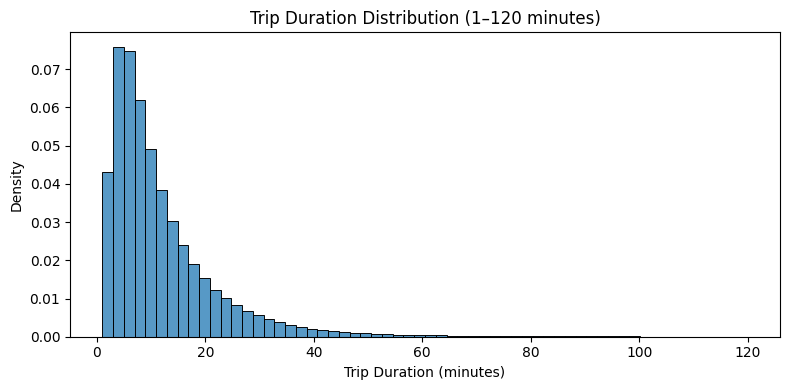

In [19]:
df_duration = con.execute("""
SELECT
    EXTRACT(EPOCH FROM (ended_ts - started_ts)) / 60 AS duration_min
FROM citibike_typed_clean
WHERE ended_ts > started_ts
  AND EXTRACT(EPOCH FROM (ended_ts - started_ts)) / 60 BETWEEN 1 AND 120
""").fetchdf()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(
    df_duration["duration_min"],
    bins=60,
    stat="density"
)

plt.title("Trip Duration Distribution (1–120 minutes)")
plt.xlabel("Trip Duration (minutes)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()


### Categorical distribution (member vs casual)

In [24]:
con.execute("""
SELECT
    member_casual,
    COUNT(*) AS trips
FROM citibike_typed
GROUP BY member_casual
""").fetchdf()

,member_casual,trips
0,member,24171478
1,casual,5314093


 ## 🔗 PHASE 5 — TIME-BASED ANALYSIS

### Monthly trend

In [25]:
df_month = con.execute("""
SELECT
    strftime('%Y-%m', started_at) AS month,
    COUNT(*) AS trips
FROM citibike_typed
GROUP BY month
ORDER BY month
""").fetchdf()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

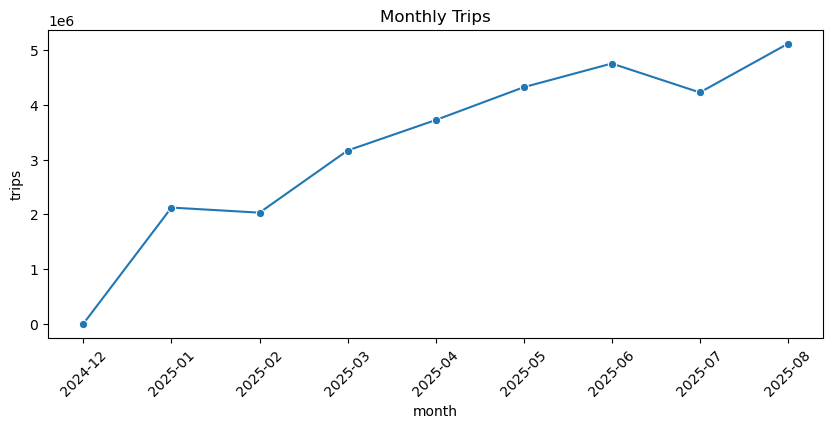

In [26]:
plt.figure(figsize=(10,4))
sns.lineplot(data=df_month, x="month", y="trips", marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Trips")
plt.show()

### Hourly usage

In [27]:
df_hour = con.execute("""
SELECT
    EXTRACT(HOUR FROM started_at) AS hour,
    COUNT(*) AS trips
FROM citibike_typed
GROUP BY hour
ORDER BY hour
""").fetchdf()

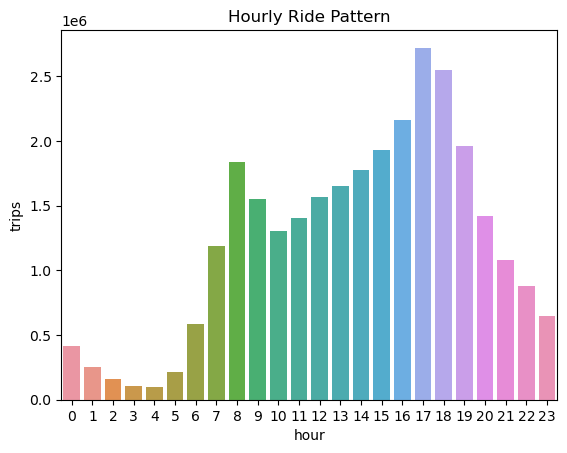

In [28]:
sns.barplot(data=df_hour, x="hour", y="trips")
plt.title("Hourly Ride Pattern")
plt.show()

### Weekday vs Weekend

In [29]:
con.execute("""
SELECT
    CASE 
        WHEN EXTRACT(DOW FROM started_at) IN (0,6) THEN 'Weekend'
        ELSE 'Weekday'
    END AS day_type,
    COUNT(*) AS trips
FROM citibike_typed
GROUP BY day_type
""").fetchdf()

,day_type,trips
0,Weekday,21491051
1,Weekend,7994520


## WEATHER RELATIONSHIP

### Temperature vs trips

In [30]:
# df_temp = con.execute("""
# SELECT
#     ROUND(temp,1) AS temperature,
#     COUNT(*) AS trips
# FROM citibike_typed
# WHERE temp IS NOT NULL
# GROUP BY temperature
# ORDER BY temperature
# """).fetchdf()

df_temp = con.execute("""
SELECT
    ROUND((temp - 32) * 5.0 / 9.0, 1) AS temperature_c,
    COUNT(*) AS trips
FROM citibike_typed
WHERE temp IS NOT NULL
GROUP BY temperature_c
ORDER BY temperature_c
""").fetchdf()



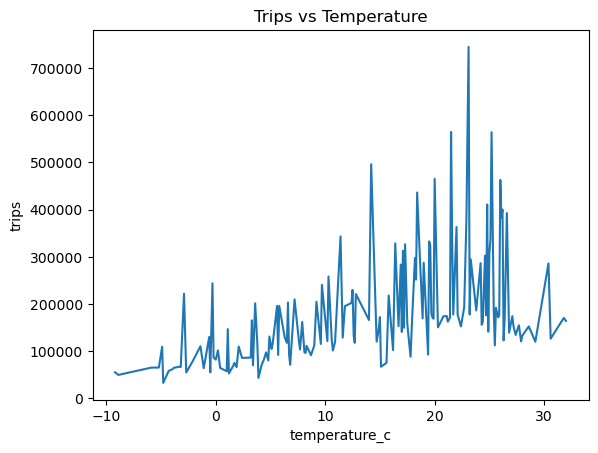

In [31]:
sns.lineplot(data=df_temp, x="temperature_c", y="trips")
plt.title("Trips vs Temperature")
plt.show()

### Rain impact

In [32]:
con.execute("""
SELECT
    CASE WHEN prcp > 0 THEN 'Rainy' ELSE 'No Rain' END AS rain_flag,
    COUNT(*) AS trips
FROM citibike_typed
GROUP BY rain_flag
""").fetchdf()

,rain_flag,trips
0,Rainy,10307165
1,No Rain,19178406


## CONSISTENCY CHECK

In [33]:
con.execute("""
SELECT
    strftime('%Y-%m', started_at) AS month,
    COUNT(*) AS rows
FROM citibike_typed
GROUP BY month
ORDER BY month
""").fetchdf()

,month,rows
0,2024-12,207
1,2025-01,2124541
2,2025-02,2031394
3,2025-03,3167962
4,2025-04,3725037
5,2025-05,4325897
6,2025-06,4759239
7,2025-07,4230051
8,2025-08,5121243


In [20]:
summary = {
    "Total Rows": con.execute("SELECT COUNT(*) FROM citibike_typed").fetchone()[0],
    "Unique Stations": con.execute("SELECT COUNT(DISTINCT start_lat || start_lng) FROM citibike_typed").fetchone()[0],
    "Duplicate Rides": con.execute("SELECT COUNT(*) - COUNT(DISTINCT ride_id) FROM citibike_typed").fetchone()[0]
}

summary

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

{'Total Rows': 29485571, 'Unique Stations': 2184, 'Duplicate Rides': 0}

## OUTLIER CHECK

#### trip duration (minutes)

In [21]:
df_duration = con.execute("""
SELECT
    EXTRACT(EPOCH FROM (ended_at - started_at)) / 60 AS duration_min
FROM citibike_typed
WHERE ended_at > started_at
""").fetchdf()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

#### Detect unrealistic duration outliers

In [22]:
con.execute("""
SELECT
    COUNT(*) AS outlier_trips
FROM citibike_typed
WHERE EXTRACT(EPOCH FROM (ended_at - started_at)) / 60 > 1440
""").fetchdf()

,outlier_trips
0,6155


#### Detect impossible temperature values

In [37]:
con.execute("""
SELECT
    MIN((temp - 32) * 5.0 / 9.0) AS min_temp_c,
    MAX((temp - 32) * 5.0 / 9.0) AS max_temp_c
FROM citibike_typed
WHERE temp IS NOT NULL
""").fetchdf()

,min_temp_c,max_temp_c
0,-9.166667,32.0


#### OUTLIER CHECK — PRECIPITATION

In [38]:
con.execute("""
SELECT COUNT(*) AS prcp_outliers
FROM citibike_typed
WHERE prcp < 0
""").fetchdf()

,prcp_outliers
0,0


#### OUTLIER CHECK — WIND SPEED

In [39]:
con.execute("""
SELECT
    MIN(wdsp) AS min_wind,
    MAX(wdsp) AS max_wind
FROM citibike_typed
WHERE wdsp IS NOT NULL
""").fetchdf()

,min_wind,max_wind
0,0.7,12.7


In [40]:
con.execute("""
SELECT COUNT(*) AS wind_outliers
FROM citibike_typed
WHERE wdsp < 0 OR wdsp > 150
""").fetchdf()


,wind_outliers
0,0


In [24]:
# con.execute("""
# CREATE OR REPLACE VIEW citibike_typed1 AS
# SELECT
#     ride_id,
#     rideable_type,

#     CAST(started_at AS TIMESTAMP) AS started_at,
#     CAST(ended_at AS TIMESTAMP) AS ended_at,

#     start_station_id,
#     start_station_name,
#     end_station_id,
#     end_station_name,

#     CAST(start_lat AS DOUBLE) AS start_lat,
#     CAST(start_lng AS DOUBLE) AS start_lng,
#     CAST(end_lat AS DOUBLE) AS end_lat,
#     CAST(end_lng AS DOUBLE) AS end_lng,

#     member_casual,
#     trip_date,

#     CAST(TEMP AS DOUBLE) AS temp,
#     CAST(PRCP AS DOUBLE) AS prcp,
#     CAST(SNDP AS DOUBLE) AS sndp
            
# FROM '{PARQUET_PATH}'
# """)



con.execute(f"""
CREATE OR REPLACE VIEW citibike_typed1 AS
SELECT
ride_id,
    rideable_type,

    CAST(started_at AS TIMESTAMP) AS started_at,
    CAST(ended_at AS TIMESTAMP) AS ended_at,

    start_station_id,
    start_station_name,
    end_station_id,
    end_station_name,

    CAST(start_lat AS DOUBLE) AS start_lat,
    CAST(start_lng AS DOUBLE) AS start_lng,
    CAST(end_lat AS DOUBLE) AS end_lat,
    CAST(end_lng AS DOUBLE) AS end_lng,

    member_casual,
    trip_date,

    CAST(TEMP AS DOUBLE) AS temp,
    CAST(PRCP AS DOUBLE) AS prcp,
    CAST(SNDP AS DOUBLE) AS sndp
FROM '{PARQUET_PATH}'
""")

## KPI 1 

#### Average Trip Duration (Monthly)

In [25]:
kpi1_avg_duration = con.execute("""
SELECT
    strftime('%Y-%m', started_at) AS month,
    ROUND(
        AVG(EXTRACT(EPOCH FROM (ended_at - started_at)) / 60),
        2
    ) AS avg_trip_duration_min
FROM citibike_typed1
WHERE ended_at > started_at
GROUP BY month
ORDER BY month
""").fetchdf()

kpi1_avg_duration


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,month,avg_trip_duration_min
0,2024-12,244.80
1,2025-01,9.76
2,2025-02,10.17
3,2025-03,11.68
4,2025-04,12.53
5,2025-05,13.39
6,2025-06,13.64
7,2025-07,14.43
8,2025-08,14.59


#### Average Trip Duration (Daily)

In [26]:
kpi1_daily_avg_duration = con.execute("""
SELECT
    DATE(started_at) AS trip_date,
    ROUND(
        AVG(EXTRACT(EPOCH FROM (ended_at - started_at)) / 60),
        2
    ) AS avg_trip_duration_min
FROM citibike_typed1
WHERE ended_at > started_at
GROUP BY DATE(started_at)
ORDER BY DATE(started_at)
""").fetchdf()

kpi1_daily_avg_duration


,trip_date,avg_trip_duration_min
0,2024-12-30,1499.89
1,2024-12-31,238.71
2,2025-01-01,12.10
3,2025-01-02,10.18
4,2025-01-03,10.20
...,...,...
240,2025-08-27,13.03
241,2025-08-28,13.26
242,2025-08-29,14.16
243,2025-08-30,16.63


## KPI 2

#### Station Demand Ranking (Monthly)

In [27]:
kpi2_station_demand_monthly = con.execute("""
SELECT
    month,
    station_id,
    trips
FROM (
    SELECT
        strftime('%Y-%m', started_at) AS month,
        start_station_id AS station_id,
        COUNT(*) AS trips,
        ROW_NUMBER() OVER (
            PARTITION BY strftime('%Y-%m', started_at)
            ORDER BY COUNT(*) DESC
        ) AS rn
    FROM citibike_typed1
    WHERE start_station_id IS NOT NULL
    GROUP BY strftime('%Y-%m', started_at), start_station_id
)
WHERE rn <= 10
ORDER BY month, trips DESC
""").fetchdf()

kpi2_station_demand_monthly


,month,station_id,trips
0,2024-12,6896.16,5
1,2024-12,4166.08,5
2,2024-12,6492.04,4
3,2024-12,6474.11,3
4,2024-12,6717.06,3
...,...,...,...
85,2025-08,5980.10,14774
86,2025-08,5905.12,14532
87,2025-08,5492.05,14420
88,2025-08,6492.08,14404


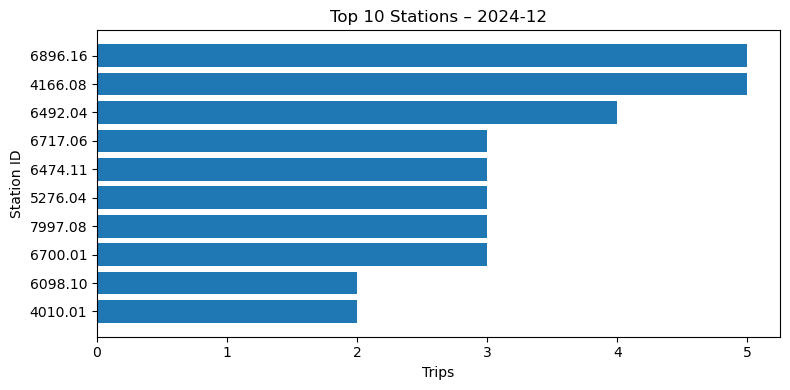

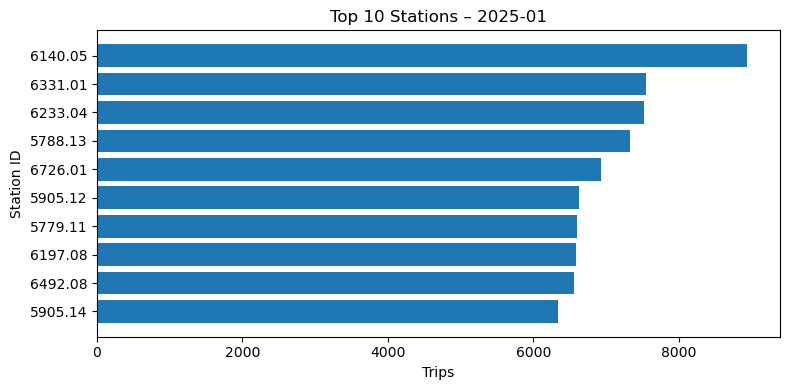

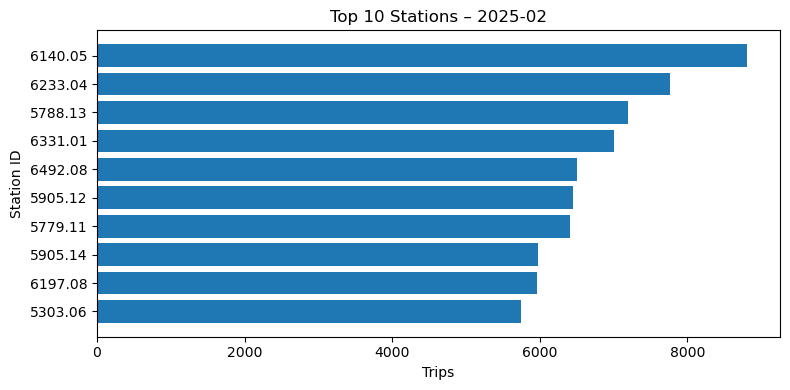

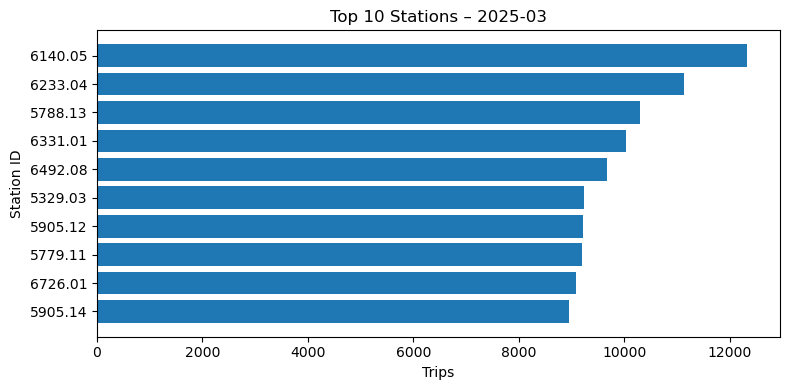

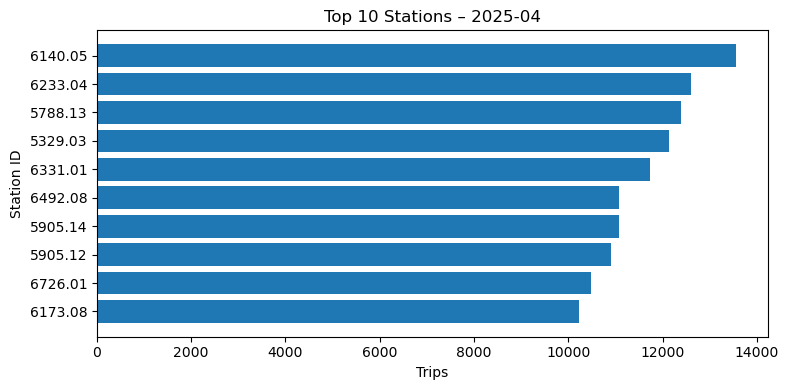

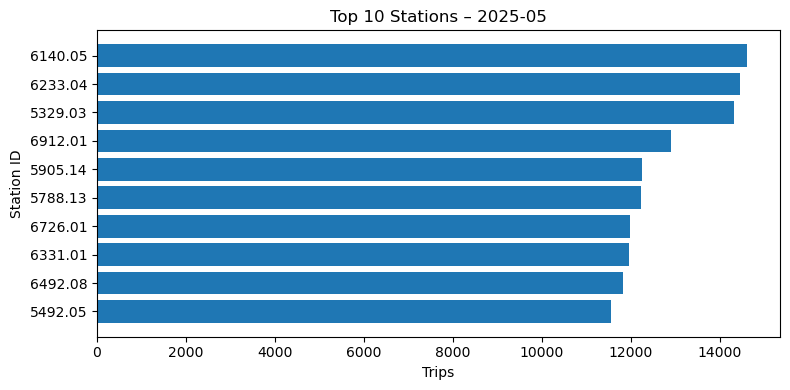

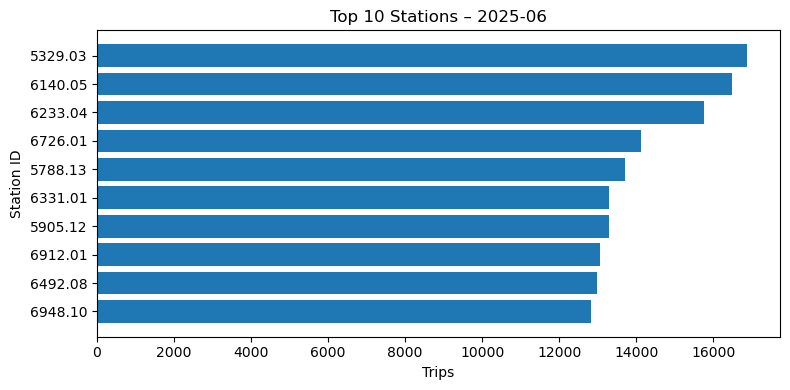

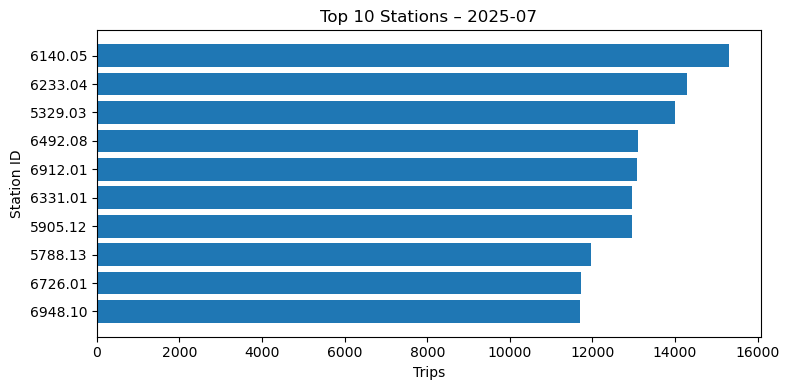

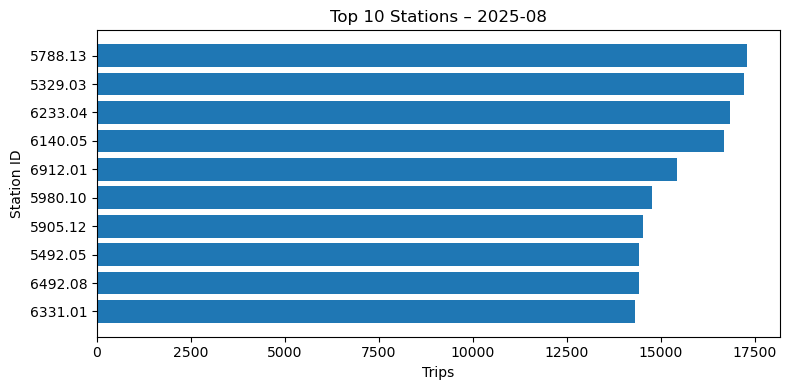

In [45]:
df = kpi2_station_demand_monthly.copy()

import matplotlib.pyplot as plt

months = df["month"].unique()

for m in months:
    temp = df[df["month"] == m]

    plt.figure(figsize=(8,4))
    plt.barh(temp["station_id"].astype(str), temp["trips"])
    plt.gca().invert_yaxis()
    plt.title(f"Top 10 Stations – {m}")
    plt.xlabel("Trips")
    plt.ylabel("Station ID")
    plt.tight_layout()
    plt.show()


## KPI 3

#### Station Imbalance Index (Monthly)

In [46]:
con.execute(f"""
CREATE OR REPLACE VIEW citibike_typed1 AS
SELECT
    ride_id,
    rideable_type,

    CAST(started_at AS TIMESTAMP) AS started_at,
    CAST(ended_at AS TIMESTAMP) AS ended_at,

    start_station_id,
    start_station_name,
    end_station_id,
    end_station_name,

    CAST(start_lat AS DOUBLE) AS start_lat,
    CAST(start_lng AS DOUBLE) AS start_lng,
    CAST(end_lat AS DOUBLE) AS end_lat,
    CAST(end_lng AS DOUBLE) AS end_lng,

    member_casual,
    trip_date,

    CAST(TEMP AS DOUBLE) AS temp,
    CAST(PRCP AS DOUBLE) AS prcp,
    CAST(SNDP AS DOUBLE) AS sndp
FROM '{PARQUET_PATH}'
""")


Candidate bindings:
"start_lat", "start_lng", "started_at", "ride_id"


### FIRST check what columns actually exist

import duckdb

con = duckdb.connect()

con.execute(f"""
DESCRIBE SELECT * FROM '{PARQUET_PATH}'
""").df()


### FIX the VIEW (remove missing columns)

In [47]:
con.execute(f"""
CREATE OR REPLACE VIEW citibike_typed1 AS
SELECT
    ride_id,
    rideable_type,

    CAST(started_at AS TIMESTAMP) AS started_at,
    CAST(ended_at AS TIMESTAMP) AS ended_at,

    CAST(start_lat AS DOUBLE) AS start_lat,
    CAST(start_lng AS DOUBLE) AS start_lng,
    CAST(end_lat AS DOUBLE) AS end_lat,
    CAST(end_lng AS DOUBLE) AS end_lng,

    member_casual,
    trip_date,

    CAST(temp AS DOUBLE) AS temp,
    CAST(prcp AS DOUBLE) AS prcp,
    CAST(sndp AS DOUBLE) AS sndp
FROM '{PARQUET_PATH}'
""")


### KPI-3: Monthly ride count

In [48]:
kpi3 = con.execute("""
SELECT
    DATE_TRUNC('month', started_at) AS month,
    COUNT(*) AS total_rides
FROM citibike_typed1
GROUP BY month
ORDER BY month
""").df()

kpi3


,month,total_rides
0,2024-12-01,207
1,2025-01-01,2124541
2,2025-02-01,2031394
3,2025-03-01,3167962
4,2025-04-01,3725037
5,2025-05-01,4325897
6,2025-06-01,4759239
7,2025-07-01,4230051
8,2025-08-01,5121243


In [49]:
con.execute(f"SELECT * FROM '{PARQUET_PATH}' LIMIT 5").df()


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,trip_date,STATION,LATITUDE,LONGITUDE,ELEVATION,NAME,TEMP,TEMP_ATTRIBUTES,DEWP,DEWP_ATTRIBUTES,SLP,SLP_ATTRIBUTES,STP,STP_ATTRIBUTES,VISIB,VISIB_ATTRIBUTES,WDSP,WDSP_ATTRIBUTES,MXSPD,GUST,MAX,MAX_ATTRIBUTES,MIN,MIN_ATTRIBUTES,PRCP,PRCP_ATTRIBUTES,SNDP,FRSHTT
0,ACCC919B5A3CD9AD,electric_bike,2025-01-01 14:52:26.542,2025-01-01 14:59:53.427,W 20 St & 7 Ave,6182.02,E 10 St & 2 Ave,5746.02,40.74238787,-73.99726235,40.72970805644994,-73.9865979552269,casual,2025-01-01,72505394728.0,40.77898,-73.96925,42.7,"NY CITY CENTRAL PARK, NY US",46.2,24.0,39.2,24.0,1000.9,16.0,995.5,24.0,7.8,24.0,6.2,24.0,13.0,32.1,53.1,,42.1,,0.4,G,999.9,10000.0
1,1FABDF3EE40FCB0E,classic_bike,2025-01-10 05:03:13.646,2025-01-10 05:13:13.331,W 20 St & 7 Ave,6182.02,E 25 St & 1 Ave,6004.07,40.74238787,-73.99726235,40.7381765,-73.97738662,member,2025-01-10,72505394728.0,40.77898,-73.96925,42.7,"NY CITY CENTRAL PARK, NY US",31.4,24.0,13.5,24.0,1012.2,24.0,7.3,24.0,10.0,24.0,9.2,23.0,15.0,28.9,39.0,,21.9,,0.0,G,999.9,0.0
2,88F0F3CFCBC79652,classic_bike,2025-01-13 13:40:17.630,2025-01-13 13:47:05.817,St James Pl & Oliver St,5238.05,Fulton St & William St,5137.11,40.71307916,-73.99851193,40.70960089363537,-74.00655090808868,member,2025-01-13,72505394728.0,40.77898,-73.96925,42.7,"NY CITY CENTRAL PARK, NY US",37.7,24.0,19.6,24.0,1014.7,24.0,9.8,24.0,10.0,24.0,3.7,22.0,9.9,17.1,42.1,,30.0,,0.0,G,999.9,0.0
3,6FDE4E191D58E453,electric_bike,2025-01-10 08:29:16.996,2025-01-10 08:34:49.360,St James Pl & Oliver St,5238.05,Fulton St & William St,5137.11,40.71307916,-73.99851193,40.70960089363537,-74.00655090808868,member,2025-01-10,72505394728.0,40.77898,-73.96925,42.7,"NY CITY CENTRAL PARK, NY US",31.4,24.0,13.5,24.0,1012.2,24.0,7.3,24.0,10.0,24.0,9.2,23.0,15.0,28.9,39.0,,21.9,,0.0,G,999.9,0.0
4,E9B03B9F77A85455,electric_bike,2025-01-11 18:59:48.427,2025-01-11 19:13:21.292,E 33 St & 1 Ave,6197.08,Allen St & Rivington St,5414.06,40.74322681432173,-73.97449783980846,40.72019576,-73.98997825,member,2025-01-11,72505394728.0,40.77898,-73.96925,42.7,"NY CITY CENTRAL PARK, NY US",32.7,24.0,19.2,24.0,1003.2,18.0,997.5,24.0,9.2,24.0,4.8,23.0,12.0,22.0,39.0,,27.0,,0.02,G,999.9,1000.0


### Get KPI-3 data from DuckDB

In [50]:
kpi3 = con.execute("""
SELECT
    DATE_TRUNC('month', started_at) AS month,
    COUNT(*) AS total_rides
FROM citibike_typed1
GROUP BY month
ORDER BY month
""").df()

kpi3


,month,total_rides
0,2024-12-01,207
1,2025-01-01,2124541
2,2025-02-01,2031394
3,2025-03-01,3167962
4,2025-04-01,3725037
5,2025-05-01,4325897
6,2025-06-01,4759239
7,2025-07-01,4230051
8,2025-08-01,5121243


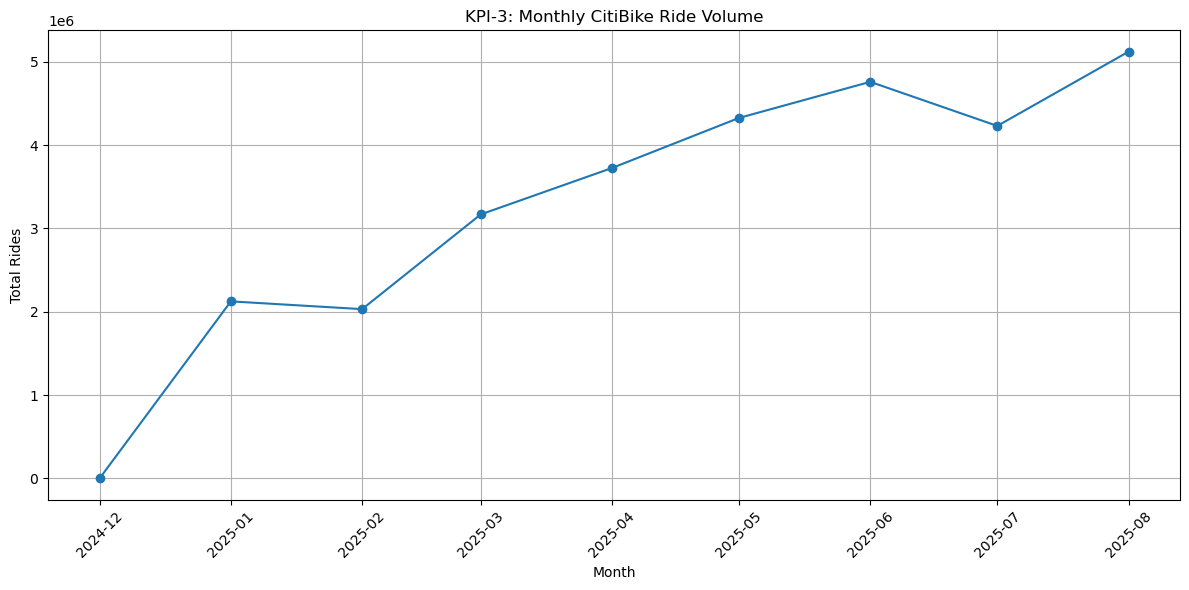

In [57]:
import matplotlib.pyplot as plt
import pandas as pd

kpi3['month'] = pd.to_datetime(kpi3['month'])

plt.figure(figsize=(12, 6))
plt.plot(kpi3['month'], kpi3['total_rides'], marker='o')

plt.title("KPI-3: Monthly CitiBike Ride Volume")
plt.xlabel("Month")
plt.ylabel("Total Rides")

plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## KPI 4 -Weather Impact Score


#### 4A — Rain Impact


In [51]:
kpi4_rain_impact = con.execute("""
SELECT
    CASE 
        WHEN prcp > 0 THEN 'Rainy Day'
        ELSE 'No Rain'
    END AS weather_type,
    COUNT(*) AS trips
FROM citibike_typed
GROUP BY weather_type
""").fetchdf()

kpi4_rain_impact


,weather_type,trips
0,No Rain,19178406
1,Rainy Day,10307165


#### 4B — Temperature Impact (°C Buckets)


In [52]:
kpi4_temp_impact = con.execute("""
SELECT
    CASE
        WHEN (temp - 32) * 5.0 / 9.0 < 0 THEN 'Below 0°C'
        WHEN (temp - 32) * 5.0 / 9.0 BETWEEN 0 AND 10 THEN '0–10°C'
        WHEN (temp - 32) * 5.0 / 9.0 BETWEEN 10 AND 20 THEN '10–20°C'
        WHEN (temp - 32) * 5.0 / 9.0 BETWEEN 20 AND 30 THEN '20–30°C'
        ELSE 'Above 30°C'
    END AS temp_bucket,
    COUNT(*) AS trips
FROM citibike_typed
WHERE temp IS NOT NULL
GROUP BY temp_bucket
ORDER BY temp_bucket
""").fetchdf()

kpi4_temp_impact


,temp_bucket,trips
0,0–10°C,5051097
1,10–20°C,9705367
2,20–30°C,11479361
3,Above 30°C,748067
4,Below 0°C,1881991


#### 4C — Weather Impact Score (Normalized)

In [53]:
kpi4_weather_score = con.execute("""
SELECT
    ROUND(
        AVG(
            CASE 
                WHEN prcp > 0 THEN -1
                WHEN (temp - 32) * 5.0 / 9.0 BETWEEN 15 AND 25 THEN 1
                ELSE 0
            END
        ),
        2
    ) AS weather_impact_score
FROM citibike_typed
""").fetchdf()

kpi4_weather_score


,weather_impact_score
0,-0.09


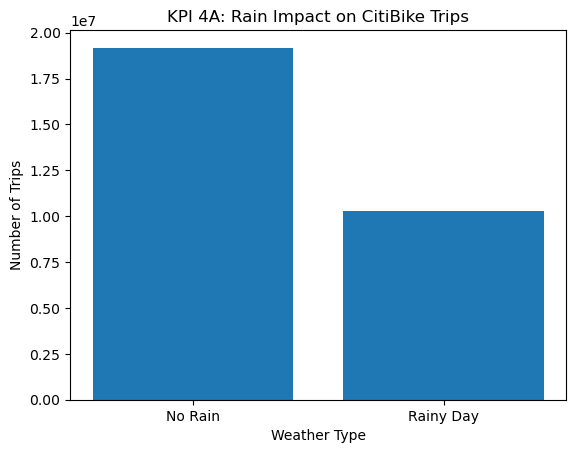

In [54]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(
    kpi4_rain_impact["weather_type"],
    kpi4_rain_impact["trips"]
)
plt.title("KPI 4A: Rain Impact on CitiBike Trips")
plt.xlabel("Weather Type")
plt.ylabel("Number of Trips")
plt.show()


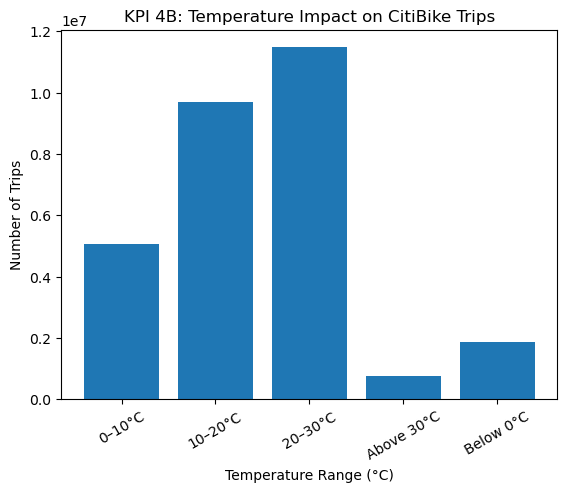

In [55]:
plt.figure()
plt.bar(
    kpi4_temp_impact["temp_bucket"],
    kpi4_temp_impact["trips"]
)
plt.title("KPI 4B: Temperature Impact on CitiBike Trips")
plt.xlabel("Temperature Range (°C)")
plt.ylabel("Number of Trips")
plt.xticks(rotation=30)
plt.show()


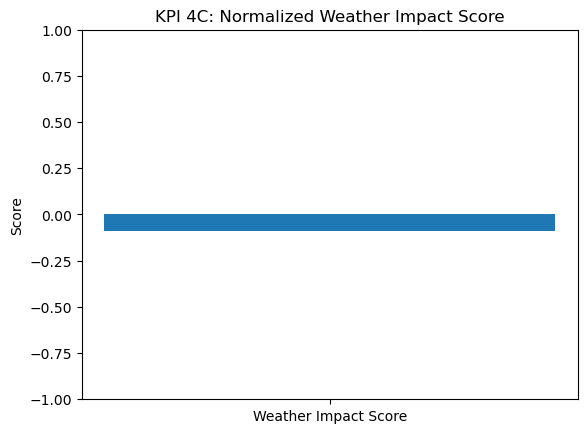

In [56]:
plt.figure()
plt.bar(
    ["Weather Impact Score"],
    kpi4_weather_score["weather_impact_score"]
)
plt.title("KPI 4C: Normalized Weather Impact Score")
plt.ylabel("Score")
plt.ylim(-1, 1)
plt.show()
